# New Section -Modules & Libraries Importation

In [1]:
import os
import sys
import time
import json
import tqdm
from types import SimpleNamespace
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets
from torchvision import transforms
import torch.optim as optim
from torchvision.datasets import CIFAR10
import torch.utils.data as data
from torch.utils.data import DataLoader
import random

import matplotlib.pyplot as plt
import numpy as np

In [2]:
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
data_path = "data_path"
checkpoint_path = "checkpoint_path"


def set_seed(seed):
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
     torch.cuda.manual_seed(seed)
     torch.cuda.manual_seed_all(seed)

set_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda:0


# Pretrained_Models

In [3]:
import os
import urllib.request
from urllib.error import HTTPError

data_path = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/"

pretrained_models =["GoogleNet.ckpt", "ResNet.ckpt", "ResNetPreAct.ckpt", "DenseNet.ckpt",
                    "tensorboards/GoogleNet/events.out.tfevents.googlenet",
                    "tensorboards/ResNet/events.out.tfevents.resnet",
                    "tensorboards/ResNetPreAct/events.out.tfevents.resnetpreact",
                    "tensorboards/DenseNet/events.out.tfevents.densenet"]

def pretrained_list(data_path = data_path, pretrained_filename = pretrained_models):
  os.makedirs(checkpoint_path, exist_ok = True)
  for file in pretrained_filename:
    file_path = os.path.join(checkpoint_path, file)
    if "/" in file:
        os.makedirs(file_path.rsplit("/",1)[0], exist_ok=True)
    if not os.path.isfile(file_path):
       file_url = data_path + file
       print(f"downloading this file{file_url}")
       try:
         urllib.request.urlretrieve(file_url, file_path)
       except HTTPError as e:
        print("downloading this filename from the google drive/n",e)

pretrained_list()




downloading this filehttps://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/GoogleNet.ckpt
downloading this filehttps://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/ResNet.ckpt
downloading this filehttps://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/ResNetPreAct.ckpt
downloading this filehttps://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/DenseNet.ckpt
downloading this filehttps://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/tensorboards/GoogleNet/events.out.tfevents.googlenet
downloading this filehttps://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/tensorboards/ResNet/events.out.tfevents.resnet
downloading this filehttps://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/tensorboards/ResNetPreAct/events.out.tfevents.resnetpreact
downloading this filehttps://raw.githubusercontent.com/phlippe/saved_models/main/tutorial5/tensorboards/DenseNet/events.out.tfevents.densenet


preprocessing the Dataset

In [4]:
train_dataset = CIFAR10(root = data_path, train = True, download = True, transform = transforms)
train_mean = (train_dataset.data/255.0).mean(axis = (0, 1, 2))
train_std = (train_dataset.data/255.0).std(axis = (0, 1, 2))

print(train_mean)
print(train_std)

100%|██████████| 170M/170M [00:42<00:00, 4.05MB/s]


[0.49139968 0.48215841 0.44653091]
[0.24703223 0.24348513 0.26158784]


In [5]:
train_transform = transforms.Compose([transforms.ToTensor(),
                                      transforms.RandomHorizontalFlip(p = 0.5),
                                      transforms.RandomResizedCrop((32, 32), scale = (0.2, 0.8), ratio = (0.2, 0.8)),
                                      transforms.Normalize(train_mean,train_std)])

test_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize(train_mean, train_std)])
train_dataset = CIFAR10(root = data_path, download = True, train = True,  transform = train_transform)
val_dataset = CIFAR10(root = data_path, download = True, train = True, transform = train_transform)
test_dataset = CIFAR10(root = data_path, download = True, train = False, transform = test_transform)

train_full_train = int(0.8 * len(train_dataset))
val_full_train = len(train_dataset) - train_full_train
split_generator = torch.Generator().manual_seed(42)
train_dataset, _ = torch.utils.data.random_split(train_dataset, [train_full_train, val_full_train])
_, val_dataset = torch.utils.data.random_split(val_dataset, [train_full_train, val_full_train])

train_loader = data.DataLoader(train_dataset, batch_size = 128, shuffle = True,num_workers = 0, pin_memory_device = device)
val_loader = data.DataLoader(val_dataset, batch_size = 128, shuffle = False, num_workers = 0, pin_memory_device = device)
test_loader = data.DataLoader(test_dataset, batch_size = 128, shuffle = False, num_workers = 0, pin_memory_device = 0)


print(train_loader)
print(val_loader)
print(test_loader)

In [6]:
img, _ = next(iter(train_loader))
print("img_standard_deviation", img.std(axis = (0,2,3)))
print("img_mean", img.mean(axis = (0,2,3)))

img_standard_deviation tensor([0.9542, 0.9424, 0.9173])
img_mean tensor([ 0.0237, -0.0246, -0.0486])


Augmentation of the images

In [7]:
num_images = 10
img

tensor([[[[-1.0367, -1.0419, -1.0613,  ..., -1.3302, -1.3366, -1.3383],
          [-1.0913, -1.0905, -1.0877,  ..., -1.2818, -1.3049, -1.3111],
          [-1.0881, -1.0823, -1.0611,  ..., -1.2009, -1.2267, -1.2337],
          ...,
          [-1.1188, -1.1056, -1.0563,  ..., -0.4756, -0.4289, -0.4164],
          [-1.1707, -1.1486, -1.0666,  ..., -0.7844, -0.7501, -0.7408],
          [-1.1161, -1.0970, -1.0261,  ..., -1.0737, -1.1446, -1.1637]],

         [[-0.9817, -0.9834, -0.9900,  ..., -1.5937, -1.5937, -1.5937],
          [-1.0093, -1.0081, -1.0034,  ..., -1.5102, -1.5215, -1.5245],
          [-1.0262, -1.0191, -0.9925,  ..., -1.3732, -1.3863, -1.3899],
          ...,
          [-1.2288, -1.1969, -1.0784,  ..., -0.5215, -0.5046, -0.5000],
          [-1.3317, -1.2899, -1.1346,  ..., -0.8408, -0.8695, -0.8772],
          [-1.2072, -1.1790, -1.0743,  ..., -1.0655, -1.1898, -1.2233]],

         [[-1.1373, -1.1406, -1.1528,  ..., -1.4667, -1.4789, -1.4821],
          [-1.1373, -1.1392, -

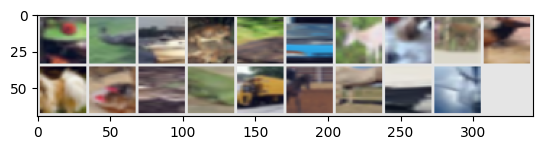

In [8]:
num_images = 19
# Collect transformed image tensors directly from the Subset
images_to_grid = []
for idx in range(num_images):
    # train_dataset[idx][0] returns the already transformed image tensor
    images_to_grid.append(train_dataset[idx][0])

# Use torch.stack to combine the list of tensors into a single tensor
img_grid = torchvision.utils.make_grid(torch.stack(images_to_grid, dim = 0), nrow = 10, normalize = True, pad_value = 0.9)

img_grid = img_grid.permute(1, 2, 0)
plt.imshow(img_grid)
plt.figure(figsize = (8,8))
plt.title("Augmented Images")
plt.axis()
plt.close()

In [9]:
!pip install  --quiet pytorch_lightning


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.5 MB/s eta 0:00:00


In [10]:
import pytorch_lightning as pl

In [11]:
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [12]:
class CIFAR100Modules(pl.LightningModule):

  def __init__(self, model_name,model_hparams, optimizer_name, optimizer_hparams):
    super().__init__()
    self.save_hyperparameters()
    self.model = create_model(model_name, model_hparams)
    self.loss_modules = nn.CrossEntropyLoss()

    self.example_input_array = torch.zeros((1,3, 32,32), dtype = torch.float32)


  def forward(self, img):
    return self.model(img)



  def configure_optimizers(self):
      if self.hparams.optimizer_name == "Adam":
         optimizer = optim.AdamW(self.parameters(), **self.hparams.optimizer_hparams)
      elif self.hparams.optimizer_name == "SGD":
          optimizer = optim.SGD(self.parameters(), **self.hparams.optimizer_hparams)
      else:
          assert False, f"unknown-values of the optimizer : {self.hparams.optimizer_name}"

      scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones = [100, 150], gamma = 0.1)
      return [optimizer],[scheduler]


  def training_step(self, batch, batch_idx):
    img, labels = batch
    pred = self.model(img)
    loss = self.loss_modules(pred, labels)
    acc = (pred.argmax(dim = -1)==labels).float().mean()
    self.log("train_loss", loss)
    self.log("train_acc", acc, on_step = False,on_epoch = True)


  def validation_step(self, batch, batch_idx):
    img, labels = batch
    pred = self.model(img)
    acc = (pred.argmax(dim = -1)== labels).float().mean()

    self.log("val_acc", acc, on_step = False, on_epoch = True)

  def test_step(self, batch, batch_idx):
    img, labels = batch
    pred = self.model(img)
    acc = (pred.argmax(dim = -1)==labels).float().mean()

    self.log("test_acc", acc, on_step = False, on_epoch = True)


In [13]:
model_dict = {}

def create_model(model_name, model_hparams):
  if model_name in model_dict:
    return model_dict[model_name](**model_hparams)
  else:
      assert False, f"Unknown model name \"{model_name}\". Available models are: {str(model_dict.keys())}"

Implementing different activation values on cifar100 values

In [14]:
act_fn_by_names = {
    "tanh":nn.Tanh,
    "relu":nn.ReLU,
    "LeakyReLU":nn.LeakyReLU,
    "gelu":nn.GELU,
    "sigmoid":nn.Sigmoid
}

act_fn_by_names

{'tanh': torch.nn.modules.activation.Tanh,
 'relu': torch.nn.modules.activation.ReLU,
 'LeakyReLU': torch.nn.modules.activation.LeakyReLU,
 'gelu': torch.nn.modules.activation.GELU,
 'sigmoid': torch.nn.modules.activation.Sigmoid}

In [15]:
from pytorch_lightning.callbacks import ModelCheckpoint,LearningRateMonitor

In [16]:
def train_model(model_name, save_name = None, **kwargs):
  if save_name is None:
    save_name = model_name


    trainer = pl.Trainer(default_root_dir = os.path.join(checkpoint_path, save_name),
                         accelerator = "gpu",
                         devices = 1,
                         max_epochs = 100,
                         min_epochs = 80,
                         callbacks =[ModelCheckpoint(save_weights_only = True, monitor = "val_acc", mode = "max", verbose = False, save_last = True), LearningRateMonitor("epoch", "step")], enable_progress_bar=True)
    trainer.logger._log_graph = True
    trainer.logger._default_hp_metric = None


    pretrained_filename = os.path.join(checkpoint_path, save_name + ".ckpt")
    if os.path.isfile(pretrained_filename):
      print(f"found pretrained model at {pretrained_filename}")
      model = CIFAR100Modules.load_from_checkpoint(pretrained_filename)
    else:
      pl.seed_everything(42)
      model = CIFAR100Modules(model_name = model_name, **kwargs)
      trainer.fit(model, train_loader, val_loader)
      model = CIFAR100Modules.load_from_checkpoint(trainer.checkpoint_callback.best_model_path, map_location = device)

    train_results = trainer.test(model, train_loader, verbose = False)
    test_results = trainer.test(model, val_loader, verbose = False)

    result = {"train":train_results[0]["test_acc"], "test":test_results[0]["test_acc"]}

    return model, result


In [17]:
class InceptionBlock(nn.Module):
  def __init__(self, c_in, c_red : dict, c_out : dict, act_fn):
        """
        Inputs:
            c_in - Number of input feature maps from the previous layers
            c_red - Dictionary with keys "3x3" and "5x5" specifying the output of the dimensionality reducing 1x1 convolutions
            c_out - Dictionary with keys "1x1", "3x3", "5x5", and "max"
            act_fn - Activation class constructor (e.g. nn.ReLU)
        """
        super().__init__()

        # 1x1 convolution branch
        self.conv_1x1 = nn.Sequential(
            nn.Conv2d(c_in, c_out["1*1"], kernel_size=1),
            nn.BatchNorm2d(c_out["1*1"]),
            act_fn()
        )

        # 3x3 convolution branch
        self.conv_3x3 = nn.Sequential(
            nn.Conv2d(c_in, c_red["3*3"], kernel_size=1),
            nn.BatchNorm2d(c_red["3*3"]),
            act_fn(),
            nn.Conv2d(c_red["3*3"], c_out["3*3"], kernel_size=3, padding=1),
            nn.BatchNorm2d(c_out["3*3"]),
            act_fn()
        )

        # 5x5 convolution branch
        self.conv_5x5 = nn.Sequential(
            nn.Conv2d(c_in, c_red["5*5"], kernel_size=1),
            nn.BatchNorm2d(c_red["5*5"]),
            act_fn(),
            nn.Conv2d(c_red["5*5"], c_out["5*5"], kernel_size=5, padding=2),
            nn.BatchNorm2d(c_out["5*5"]),
            act_fn()
        )

        # Max-pool branch
        self.max_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, padding=1, stride=1),
            nn.Conv2d(c_in, c_out["max"], kernel_size=1),
            nn.BatchNorm2d(c_out["max"]),
            act_fn()
        )

  def forward(self, x):
      x_1x1 = self.conv_1x1(x)
      x_3x3 = self.conv_3x3(x)
      x_5x5 = self.conv_5x5(x)
      x_max = self.max_pool(x)
      x_out = torch.cat([x_1x1, x_3x3, x_5x5, x_max], dim=1)
      return x_out

In [18]:
class GoogleNet(nn.Module):
  def __init__(self, num_classes = 10, act_fn_name = "relu", **kwargs):
    super().__init__()
    self.hparams = SimpleNamespace(num_classes = num_classes,
                                   act_fn_name = act_fn_name,
                                   act_fn = act_fn_by_names[act_fn_name])

    self._create_model()
    self._init_params()

  def _create_model(self):
    self.input_net = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size = 3, padding = 1),
        nn.BatchNorm2d(64),
        self.hparams.act_fn()
    )


    self.inception_blocks = nn.Sequential(
        InceptionBlock(64, c_red = {"3*3":32, "5*5":16}, c_out = {"1*1":16, "3*3":32, "5*5":8, "max":8},act_fn = self.hparams.act_fn),
        InceptionBlock(64, c_red = {"3*3":32, "5*5":16}, c_out = {"1*1":24, "3*3":48, "5*5":12, "max":12}, act_fn = self.hparams.act_fn),
        nn.MaxPool2d(kernel_size = 3, padding = 1, stride = 2),
        InceptionBlock(96, c_red = {"3*3":48, "5*5":16}, c_out = {"1*1":24, "3*3":48, "5*5":12, "max":12}, act_fn = self.hparams.act_fn),
        InceptionBlock(96, c_red = {"3*3":48, "5*5":32}, c_out = {"1*1":48,"3*3":64,"5*5":8,"max":8},act_fn = self.hparams.act_fn),
        nn.MaxPool2d(kernel_size = 3, padding = 1, stride = 2),
        InceptionBlock(128, c_red = {"3*3":64, "5*5":64}, c_out = {"1*1":48, "3*3":64, "5*5":8, "max":8}, act_fn = self.hparams.act_fn),
        InceptionBlock(128, c_red = {"3*3":64, "5*5":64}, c_out ={"1*1":32, "3*3":64, "5*5":16, "max":16},act_fn = self.hparams.act_fn))

    self.output_net = nn.Sequential(
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(128, self.hparams.num_classes)
    )


  def _init_params(self):
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity = self.hparams.act_fn_name)
      elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)


  def forward(self, x):
    x = self.input_net(x)
    x = self.inception_blocks(x)
    x = self.output_net(x)
    return x

In [19]:
model_dict["Googlenet"] = GoogleNet

In [20]:
googlenet_model, google_result = train_model(model_name = "Googlenet",
                                             model_hparams = {
                                                 "num_classes":10,
                                                 "act_fn_name":"relu"},
                                             optimizer_name = "Adam",
                                             optimizer_hparams = {
                                                 "lr":1e-4,
                                                 "weight_decay":1e-2
                                             })

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name         ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃       In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model        │ GoogleNet        │  288 K │ train │ 149 M │ [1, 3, 32, 32] │   [1, 10] │
│ 1 │ loss_modules │ CrossEntropyLoss │      0 │ train │     0 │              ? │         ? │
└───┴──────────────┴──────────────────┴────────┴───────┴───────┴────────────────┴───────────┘

Trainable params: 288 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 288 K                                                                                                
Total estimated model params size (MB): 1.152                                                                      
Modules in train mode: 157                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 149 M

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [21]:
print("GoogleNet Results", google_result)

GoogleNet Results {'train': 0.1049249991774559, 'test': 0.11060000211000443}


In [22]:
test_model = create_model(
    "Googlenet",
    {
        "num_classes": 100,
        "act_fn_name": "relu"
    }
)

print(test_model)
print(type(test_model))

x = torch.randn(4, 3, 32, 32)

output = test_model(x)

print("Output:", output)
print("Output type:", type(output))

GoogleNet(
  (input_net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (inception_blocks): Sequential(
    (0): InceptionBlock(
      (conv_1x1): Sequential(
        (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (conv_3x3): Sequential(
        (0): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
      (conv_5x5): Sequential(
        (0): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
       

ResNet, PreResNet Implementation

In [23]:
class ResNetBlock(nn.Module):
  def __init__(self, c_in, act_fn, subsample = False, c_out = -1):
    super().__init__()

    if not subsample:
      c_out = c_in


    self.input_net = nn.Sequential(
          nn.Conv2d(c_in, c_out, kernel_size = 3, padding = 1, stride = 1 if not subsample else 2, bias = False),
          nn.BatchNorm2d(c_out),
          act_fn(),

          nn.Conv2d(c_out, c_out, kernel_size = 3, padding = 1, bias = False),
          nn.BatchNorm2d(c_out)
      )

    self.downsample = nn.Conv2d(c_in, c_out, kernel_size = 1, stride = 2)if subsample else None
    self.act_fn = act_fn()


  def forward(self, x):
    z = self.input_net(x)
    if self.downsample is not None:
      x = self.downsample(x)
    out = z + x
    out = self.act_fn(out)
    return out


In [24]:
class PresnetBlock(nn.Module):
  def __init__(self, c_in, act_fn, subsample = False, c_out = -1):
    super().__init__()


    if not subsample :
      c_out = c_in


    self.input_net = nn.Sequential(
        act_fn(),
        nn.BatchNorm2d(c_in),
        nn.Conv2d(c_in, c_out, kernel_size = 3, padding = 1, stride = 1 if subsample else 2, bias = False),

        nn.BatchNorm2d(c_out),
        act_fn(),
        nn.Conv2d(c_out, c_out, kernel_size = 3, padding = 1 , bias = False)

    )


    self.downsample = nn.Sequential(
        nn.BatchNorm2d(c_in),
        act_fn(),
        nn.Conv2d(c_in, c_out, kernel_size = 1, stride = 2) if subsample else None
    )

  def forward(self, x):
    x = self.input_net(x)
    if self.downsample is not None:
      o = self.downsample(x)

    out = x + o
    return out


In [25]:
resnet_block_name = {
    "resnet":ResNetBlock,
    "presnet":PresnetBlock
}

In [26]:
class ResNet_Layer(nn.Module):
  def __init__(self,  num_classes = 10, num_blocks = [3,3,3],c_hidden = [16, 32, 64], act_fn_name = "relu", block_name = "resnet_block", **kwargs):

    super().__init__()

    assert block_name in resnet_block_name

    self.hparams = SimpleNamespace(
        num_classes = num_classes,
        num_blocks = num_blocks,
        c_hidden = c_hidden,
        act_fn_name = act_fn_name,
        act_fn = act_fn_by_names[act_fn_name],
        block_named = resnet_block_name[block_name]
    )

    self._create_network()
    self._init_params()


  def _create_network(self):
    c_hidden  = self.hparams.c_hidden
    num_blocks = self.hparams.num_blocks

    if self.hparams.block_named == PresnetBlock:
      self.input_net = nn.Sequential(
          nn.Conv2d(3, c_hidden[0], kernel_size = 3, padding = 1, bias =False)
      )
    else:
      self.input_net = nn.Sequential(
          nn.Conv2d(3, c_hidden[0], kernel_size = 3, padding = 1, bias = False),
          nn.BatchNorm2d(c_hidden[0]),
          self.hparams.act_fn()
      )

    blocks = []
    for block_idx, block_count in enumerate(num_blocks):
      for bc in range(block_count):
        subsample = (bc==0 and block_idx > 0)
        blocks.append(
            self.hparams.block_named(
                c_in=c_hidden[block_idx if not subsample else(block_idx -1)],
                act_fn = self.hparams.act_fn,
                subsample = subsample,
                c_out = c_hidden[block_idx]
            )
        )

    self.blocks = nn.Sequential(*blocks)

    self.output_net = nn.Sequential(
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(c_hidden[-1], out_features = self.hparams.num_classes)
    )

  def _init_params(self):
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode = "fan_out", nonlinearity = self.hparams.act_fn_name)
      elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)


  def forward(self, x):
    x = self.input_net(x)
    x = self.blocks(x)
    x = self.output_net(x)
    return x

In [27]:
model_dict["ResNet_layer"] = ResNet_Layer

In [ ]:
resnet_models, resnet_results = train_model(model_name = "ResNet_layer",
                                            model_hparams = {
                                                "num_classes":10,
                                                "num_blocks": [3,3,3],
                                                "c_hidden": [16, 32, 64],
                                                "act_fn_name":"relu",
                                                "block_name":"resnet"},
                                            optimizer_name = "SGD",
                                            optimizer_hparams = {
                                                "lr":1e-5,
                                                "weight_decay":1e-4,
                                                "momentum":0.8
                                            }
                                            )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name         ┃ Type             ┃ Params ┃ Mode  ┃  FLOPs ┃       In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model        │ ResNet_Layer     │  272 K │ train │ 81.6 M │ [1, 3, 32, 32] │   [1, 10] │
│ 1 │ loss_modules │ CrossEntropyLoss │      0 │ train │      0 │              ? │         ? │
└───┴──────────────┴──────────────────┴────────┴───────┴────────┴────────────────┴───────────┘

Trainable params: 272 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 272 K                                                                                                
Total estimated model params size (MB): 1.090                                                                      
Modules in train mode: 85                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 81.6 M

Output()

In [ ]:
print("Resnet_model", resnet_models)

In [ ]:
print("resnet_results", resnet_results)

Desnet Implementation

In [ ]:
class DenseLayer(nn.Module):
  def __init__(self, c_in, bn_size, growth_rate, act_fn):
    super().__init__()

    self.input_net = nn.Sequential(
        nn.BatchNorm2d(c_in),
        act_fn(),
        nn.Conv2d(c_in, bn_size * growth_rate, kernel_size = 1, bias = False),

        nn.BatchNorm2d(bn_size * growth_rate),
        act_fn(),
        nn.Conv2d(bn_size * growth_rate, growth_rate, kernel_size = 3, padding = 1, bias = False)
    )


  def forward(self,x):
    out = self.input_net(x)
    x = torch.cat([out, x], dim = 1)
    return x


In [ ]:
class DenseBlock(nn.Module):
  def __init__(self,c_in, bn_size, growth_rate, num_layers, act_fn):
    super().__init__()

    layers = []
    for layer in range(num_layers):
      layers.append(DenseLayer(c_in = c_in + layer * growth_rate,
                               bn_size = bn_size,
                               growth_rate = growth_rate,
                               act_fn = act_fn))

      self.layers = nn.Sequential(*layers)

  def forward(self, x):
    x = self.layers(x)
    return x

In [ ]:
class Transitional_layer(nn.Module):
  def __init__(self, c_in, c_out, act_fn):
    super().__init__()

    self.transitional = nn.Sequential(
        nn.BatchNorm2d(c_in),
        act_fn(),
        nn.Conv2d(c_in, c_out, kernel_size = 1,  bias = False),
        nn.AdaptiveAvgPool2d(kernel_size = 2, stride = 2)
    )

  def forward(self, x):
    out = self.transitional(x)
    return out

In [ ]:
class Dense_Block(nn.Module):

  def __init__(self,  num_classes = 10,  bn_size = 2, num_layers = [6,6,6,6], growth_rate = 16, act_fn_name = "relu", **kwargs):

    super().__init__()

    self.hparams = SimpleNamespace(
                                   num_classes = num_classes,
                                   bn_size = bn_size,
                                   growth_rate = growth_rate,
                                   num_layers = num_layers,
                                   act_fn_name = act_fn_name,
                                   act_fn = act_fn_by_names[act_fn_name])

    self._create_model()
    self._init_params()


  def _create_model(self):
    c_hidden = self.hparams.growth_rate * self.hparams.bn_size


    self.input_net = nn.Sequential(
        nn.Conv2d(3, c_hidden, kernel_size = 3, padding = 1)
    )

    blocks = []

    for block, num_layers in enumerate(self.hparams.num_layers):
     blocks.append(DenseBlock(c_in = c_hidden,
                              num_layers = num_layers,
                             bn_size = self.hparams.bn_size,
                             growth_rate = self.hparams.growth_rate,
                             act_fn = self.hparams.act_fn
                             ))

    c_hidden  = c_hidden + num_layers * self.hparams.growth_rate
    if block < len(self.hparams.num_layers) -1:
      blocks.append(Transitional_layer(c_in = c_hidden,
                                       c_out = c_hidden//2,
                                       act_fn = self.hparams.act_fn))

      c_hidden = c_hidden//2

    self.blocks = nn.Sequential(*blocks)



    self.output_net = nn.Sequential(
        nn.BatchNorm2d(c_hidden),
        self.hparams.act_fn(),
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(c_hidden, self.hparams.num_classes)
    )



  def _init_params(self):
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight,  nonlinearity = self.hparams.act_fn_name)
      elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

  def forward(self, x):
    x = self.input_net(x)
    x = self.blocks(x)
    x = self.output_net(x)
    return x

In [ ]:
dense_block_model, dense_block_results = train_model(model_name = "DenseNet_Layer",
                                                     model_hparams = {
                                                         "num_classes":10,
                                                         "num_layers":[6,6,6,6],
                                                         "bn_size":2,
                                                         "growth_rate":16,
                                                         "act_fn_name":"relu"

                                                     },
                                                     optimizer_name = "Adam",
                                                     optimizer_hparams = {
                                                         "lr":1e-4,
                                                         "weight_decay":1e-5,

                                                     })

In [ ]:
model_dict["DenseNet_Layer"] = Dense_Block